# **LU decomposition**

![lu公式](../docs/formula.png)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu
import time
np.set_printoptions(suppress=True, precision=8)
rng = np.random.default_rng(7)

## 1. Implementations from scratch

In [2]:


def lu_no_pivot(A, pivot_tol=0.0):
    A_demo = A.copy().astype(float)
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros_like(A_demo)

    if pivot_tol is None:
        scale = max(1.0, np.linalg.norm(A_demo, ord=np.inf))
        pivot_tol = np.finfo(float).eps * n * scale

    for i in range (n):

        pivot = A_demo[i, i]

        if abs(pivot) <= pivot_tol:
            raise np.linalg.LinAlgError(
                f"Zero or unsafe pivot at index {i}: "
                f"|pivot| = {abs(pivot):.3e}. "
                "Use pivoting instead."
            )
        
        U[i,i:]  = A_demo[i,i:]
        if i < n-1:
            L[i+1:,i] = A_demo[i+1:,i]/A_demo[i,i]
            l_1 = L[i+1:,i]
            u_1T = U[i,i+1:]

            A_demo[i+1:,i+1:] = A_demo[i+1:,i+1:] - np.outer(l_1,u_1T)
    return L,U


def lu_partial_pivot(A):
    A_demo = A.copy().astype(float)
    n = A.shape[0]
    L = np.eye(n)
    P = np.eye(n)
    U = np.zeros_like(A_demo)

    for i in range (n):
        #Find the pivot in the current column (row index with the maximum absolute value from row i downwards)
        max_idx = i + np.argmax(np.abs(A_demo[i:, i]))
        if max_idx != i:
            A_demo[[i, max_idx], :] = A_demo[[max_idx, i], :]
            P[[i, max_idx], :] = P[[max_idx, i], :]
            if i > 0:
                L[[i, max_idx], :i] = L[[max_idx, i], :i]

        U[i,i:]  = A_demo[i,i:]

        if i < n-1:
            L[i+1:,i] = A_demo[i+1:,i]/A_demo[i,i]
            l_1 = L[i+1:,i]
            u_1T = U[i,i+1:]

            A_demo[i+1:,i+1:] = A_demo[i+1:,i+1:] - np.outer(l_1,u_1T)
    return L,U,P

## 2. Verification

In [3]:
def factorization_residual(A, P, L, U):
    denominator = max(np.linalg.norm(A, ord=np.inf), np.finfo(float).tiny)
    return np.linalg.norm(P @ A - L @ U, ord=np.inf) / denominator


A = np.array([[0.0, 2.0, 3.0],
              [4.0, 5.0, 6.0],
              [7.0, 8.0, 10.0]])
L, U, P= lu_partial_pivot(A)

assert np.allclose(P @ P.T, np.eye(A.shape[0])) #P @ P.T = I
assert np.allclose(L, np.tril(L)) and np.allclose(np.diag(L), 1.0)#L is lower triangular and all diagonal elements are 1
assert np.allclose(U, np.triu(U))#U is upper triangular
assert np.allclose(P @ A, L @ U)#P @ A = L @ U

print("P =\n", P)
print("L =\n", L)
print("U =\n", U)
print(f"normalized factorization residual = {factorization_residual(A, P, L, U):.3e}")

P =
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
L =
 [[1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.57142857 0.21428571 1.        ]]
U =
 [[ 7.          8.         10.        ]
 [ 0.          2.          3.        ]
 [ 0.          0.         -0.35714286]]
normalized factorization residual = 0.000e+00


## 3. Solving $Ax=b$ with the factors
P @ A = L @ U    A @ x = b

=> P @ A @ x = P @ b

=> L @ U @ x = P @ b

Let $y = U @ x$

=> L @ y = P @ b 

compute y via forward substitution

compute x via backward substitution


In [4]:
def forward_substitution(L, b):
    b = np.asarray(b, dtype=float)
    n = L.shape[0]
    y = np.empty_like(b, dtype=float)
    for i in range(n):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    return y


def backward_substitution(U, y):
    y = np.asarray(y, dtype=float)
    n = U.shape[0]
    x = np.empty_like(y, dtype=float)
    for i in range(n - 1, -1, -1):
        if U[i, i] == 0:
            raise np.linalg.LinAlgError("Singular upper-triangular system.")
        x[i] = (y[i] - U[i, i + 1 :] @ x[i + 1 :]) / U[i, i]
    return x

def lu_solve(P, L, U, b):
    return backward_substitution(U, forward_substitution(L, P @ b))

In [5]:
A_solve = rng.normal(size=(6, 6)) + 3.0 * np.eye(6)
x_true = rng.normal(size=6)
b = A_solve @ x_true
L, U, P= lu_partial_pivot(A_solve)
x_computed = lu_solve(P, L, U, b)

forward_error = np.linalg.norm(x_computed - x_true, ord=np.inf) / np.linalg.norm(x_true, ord=np.inf)
backward_error = np.linalg.norm(b - A_solve @ x_computed, ord=np.inf) / max((np.linalg.norm(A_solve, ord=np.inf) * np.linalg.norm(x_computed, ord=np.inf)+ np.linalg.norm(b, ord=np.inf)), np.finfo(float).tiny)

print(f"relative forward error  = {forward_error:.3e}")
print(f"relative backward error = {backward_error:.3e}")
assert np.allclose(x_computed, x_true)

relative forward error  = 2.825e-16
relative backward error = 7.090e-17


## 4. Stability experiment: why pivoting matters
Consider

$$A_\varepsilon=\begin{bmatrix}\varepsilon&1\\1&1\end{bmatrix}.$$


In [6]:
eps_values = 10.0 ** (-np.arange(1, 17, dtype=float))
error_no_pivot, error_pivot = [], []
x_true = np.array([1.0, 1.0])

for eps in eps_values:
    A_eps = np.array([[eps, 1.0], [1.0, 1.0]])
    b_eps = A_eps @ x_true

    # A zero tolerance is used only to expose the instability experimentally.
    L0, U0 = lu_no_pivot(A_eps, pivot_tol=0.0)
    x0 = backward_substitution(U0, forward_substitution(L0, b_eps))
    L1, U1, P1 = lu_partial_pivot(A_eps)
    x1 = lu_solve(P1, L1, U1, b_eps)

    error_no_pivot.append(np.linalg.norm(x0 - x_true, ord=np.inf))
    error_pivot.append(np.linalg.norm(x1 - x_true, ord=np.inf))

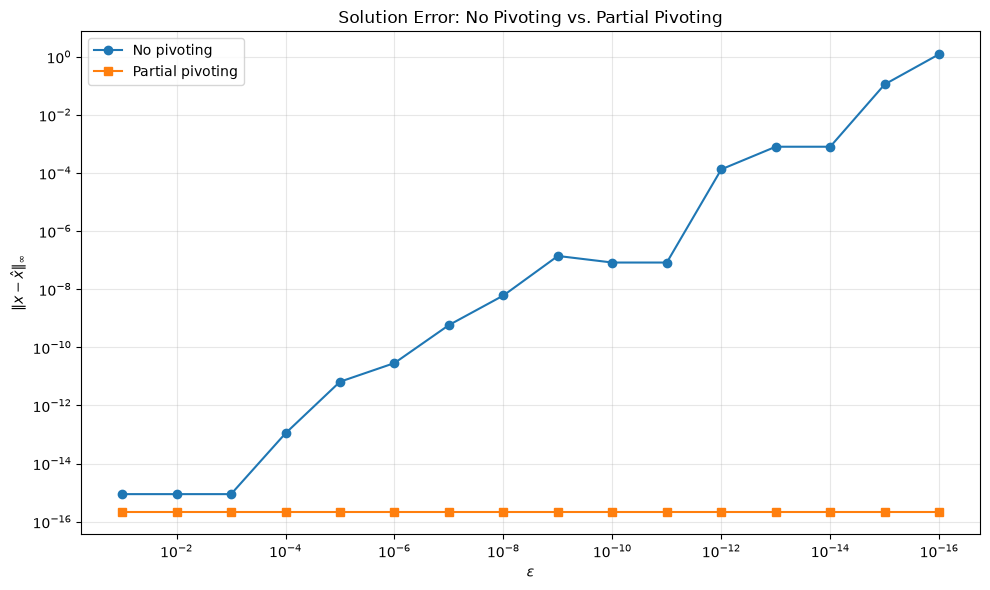

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
error_floor = np.finfo(float).eps
ax.loglog(
    eps_values,
    np.maximum(error_no_pivot, error_floor),
    "o-",
    label="No pivoting"
)
ax.loglog(
    eps_values,
    np.maximum(error_pivot, error_floor),
    "s-",
    label="Partial pivoting"
)
ax.invert_xaxis()
ax.set(
    xlabel=r"$\varepsilon$",
    ylabel=r"$\|x-\hat{x}\|_\infty$",
    title="Solution Error: No Pivoting vs. Partial Pivoting"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## 5. Empirical complexity

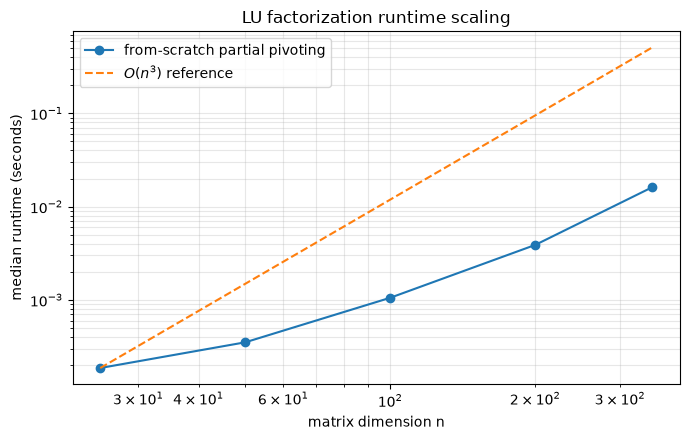

In [8]:
def median_runtime(function, A, repeats=5):
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        function(A)
        samples.append(time.perf_counter() - start)
    return np.median(samples)

sizes = np.array([25, 50, 100, 200, 350])
our_times = []

for n in sizes:
    A_n = rng.normal(size=(n, n)) + np.eye(n)
    our_times.append(median_runtime(lu_partial_pivot, A_n))

our_times = np.asarray(our_times)
reference_cubic = our_times[0] * (sizes / sizes[0]) ** 3

plt.figure(figsize=(7, 4.5))
plt.loglog(sizes, our_times, "o-", label="from-scratch partial pivoting")
plt.loglog(sizes, reference_cubic, "--", label=r"$O(n^3)$ reference")
plt.xlabel("matrix dimension n")
plt.ylabel("median runtime (seconds)")
plt.title("LU factorization runtime scaling")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
